# Soil Analysis - HWSD2 Dataset

## Analysis Structure

**Section 0: Setup & Imports**
- Configure multi-threading
- Import required libraries
- Define helper functions

**Section 1: Initial Data Loading**
- Load MDB database (tabular soil attributes)
- Load raster file (spatial soil data)
- Display dataset summary
- Quick initial assessment

**Section 2: Spatial Operations**
- Load fire point locations
- Create bounding box with buffer
- Clip raster to fire locations
- Extract soil unit IDs at fire coordinates
- Visualize clipped raster with fire overlay

**Section 3: Exploratory Data Analysis**
- Descriptive statistics
- Univariate analysis (Boxplots, Histograms)
- Bivariate analysis (Correlation matrix, Scatter plots, Q-Q plots)
- Categorical analysis (Bar plots)

**Section 4: Data Preprocessing**
- Clean soil attributes (sentinels, imputation, outliers, normalization)
- Keep all rows for proper spatial linkage (no duplicate removal)
- Validate preprocessing results
- Analyze feature normalization requirements

**Section 5: Save Results**
- Save cleaned soil data
- Save fire points with soil IDs
- Save clipped raster
- Generate summary report

In [1]:
# Configure threading for performance
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import configure_threading

configure_threading()

Threading configured to use up to 12 CPU cores.


12

In [2]:
# Import config paths
from config import (
    HWSD_MDB, HWSD_BIL,
    FIRES_WITH_ARTIFICIAL_UNSUPERVISED,
    FIRES_SUPERVISED_CSV,
    FIRES_WITH_SOIL, FIRES_WITH_SOIL_IDS, SOIL_LOG,
    RESULTS_INTERMEDIATE_DIR, ALGERIA_SHP, TUNISIA_SHP
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import geopandas as gpd
import rasterio as rio
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


In [3]:
# Helper function to load HWSD MDB database
def load_hwsd_mdb(mdb_path):
    """
    Load HWSD2 database using ODBC connection.
    Returns: pyodbc connection object or None if failed
    """
    try:
        conn_str = (
            r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
            f"DBQ={mdb_path};"
        )
        conn = pyodbc.connect(conn_str)
        return conn
    except Exception as e:
        print(f'Error connecting to MDB: {e}')
        return None

---
## Section 1: Initial Data Loading

Load the HWSD2 database and raster file, then perform a quick initial assessment.

### 1.1 Load MDB Database (Tabular Soil Attributes)

HWSD2 Dataset Features:

**Physical Properties (8 features):**
- `COARSE`, `SAND`, `SILT`, `CLAY`, `TEXTURE_USDA`, `TEXTURE_SOTER`, `BULK`, `REF_BULK`

**Chemical Properties (14 features):**
- `ORG_CARBON`, `PH_WATER`, `TOTAL_N`, `CN_RATIO`, `CEC_SOIL`, `CEC_CLAY`, `CEC_EFF`, `TEB`, `BSAT`, `ALUM_SAT`, `ESP`, `TCARBON_EQ`, `GYPSUM`, `ELEC_COND`

In [4]:
# Load the HWSD database
conn = load_hwsd_mdb(str(HWSD_MDB))

if conn:
    # Load HWSD2_LAYERS table
    df_layers = pd.read_sql("SELECT * FROM HWSD2_LAYERS", conn)
    print(f'✓ HWSD2_LAYERS loaded: {df_layers.shape}')
    
    # Filter for LAYER = 'D1' (topsoil layer)
    df_d1 = df_layers[df_layers['LAYER'] == 'D1']
    print(f'✓ Filtered D1 layer: {df_d1.shape}')
    
    # Select specific features
    features = ["COARSE", "SAND", "SILT", "CLAY", "TEXTURE_USDA", "TEXTURE_SOTER", 
                "BULK", "REF_BULK", "ORG_CARBON", "PH_WATER", "TOTAL_N", "CN_RATIO", 
                "CEC_SOIL", "CEC_CLAY", "CEC_EFF", "TEB", "BSAT", "ALUM_SAT", 
                "ESP", "TCARBON_EQ", "GYPSUM", "ELEC_COND"]
    df_soil = df_d1[features]
    print(f'✓ Selected {len(features)} features: {df_soil.shape}')
    
    conn.close()
else:
    print('Failed to connect to MDB. Please check the driver and path.')

C:\Users\Azur\AppData\Local\Temp\ipykernel_21944\3180263590.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_layers = pd.read_sql("SELECT * FROM HWSD2_LAYERS", conn)


✓ HWSD2_LAYERS loaded: (408835, 48)
✓ Filtered D1 layer: (58405, 48)
✓ Selected 22 features: (58405, 22)


In [5]:
# Check what columns are available in df_d1 for linking
print("\n" + "="*60)
print("LINKING COLUMN ANALYSIS")
print("="*60)
print(f"\nAll columns in df_d1: {df_d1.columns.tolist()}")

# Find ID columns
id_cols = [col for col in df_d1.columns if 'ID' in col.upper()]
print(f"\nColumns containing 'ID': {id_cols}")

# Check uniqueness of ID columns
for col in id_cols:
    unique_count = df_d1[col].nunique()
    total_count = len(df_d1)
    print(f"  {col}: {unique_count:,} unique values out of {total_count:,} ({unique_count/total_count*100:.2f}%)")

# Show sample of ID columns with soil properties
if id_cols:
    print(f"\nSample data with ID columns:")
    display_cols = id_cols[:2] + ['COARSE', 'SAND', 'SILT', 'CLAY']
    print(df_d1[display_cols].head(10))
    
print("="*60)


LINKING COLUMN ANALYSIS

All columns in df_d1: ['ID', 'HWSD2_SMU_ID', 'NSC_MU_SOURCE1', 'NSC_MU_SOURCE2', 'WISE30s_SMU_ID', 'HWSD1_SMU_ID', 'COVERAGE', 'SEQUENCE', 'SHARE', 'NSC', 'WRB_PHASES', 'WRB4', 'WRB2', 'FAO90', 'ROOT_DEPTH', 'PHASE1', 'PHASE2', 'ROOTS', 'IL', 'SWR', 'DRAINAGE', 'AWC', 'ADD_PROP', 'LAYER', 'TOPDEP', 'BOTDEP', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']

Columns containing 'ID': ['ID', 'HWSD2_SMU_ID', 'WISE30s_SMU_ID', 'HWSD1_SMU_ID']
  ID: 58,405 unique values out of 58,405 (100.00%)
  HWSD2_SMU_ID: 29,538 unique values out of 58,405 (50.57%)
  WISE30s_SMU_ID: 29,538 unique values out of 58,405 (50.57%)
  HWSD1_SMU_ID: 29,452 unique values out of 58,405 (50.43%)

Sample data with ID columns:
      ID  HWSD2_SMU_ID  COARSE  SAND  SILT  CLAY
666  667         12704     

### 1.2 Load Raster File (Spatial Soil Data)

In [6]:
# Load the HWSD raster data
try:
    with rio.open(str(HWSD_BIL)) as src:
        raster_data = src.read()  # Read all bands
        raster_profile = src.profile
        raster_bounds = src.bounds
        raster_crs = src.crs
        
        print('✓ Raster loaded successfully!')
        print(f'  Number of bands: {raster_data.shape[0]}')
        print(f'  Raster shape: {raster_data.shape[1]} x {raster_data.shape[2]} pixels')
        print(f'  Bounds: {raster_bounds}')
        print(f'  CRS: {raster_crs}')
        print(f'  Memory: {raster_data.nbytes / (1024**2):.2f} MB')
        
except Exception as e:
    print(f'Error loading raster: {e}')

✓ Raster loaded successfully!
  Number of bands: 1
  Raster shape: 21600 x 43200 pixels
  Bounds: BoundingBox(left=-179.99999999999966, bottom=-89.99999999999996, right=180.00000000000017, top=89.99999999999996)
  CRS: OGC:CRS84
  Memory: 1779.79 MB


### 1.3 Dataset Summary & Quick Assessment

In [7]:
# Dataset Content Summary
print("=" * 60)
print("HWSD2 DATASET SUMMARY")
print("=" * 60)
print(f"\nTabular Data (MDB):")
print(f"  Records loaded: {df_soil.shape[0]:,}")
print(f"  Features: {df_soil.shape[1]}")
print(f"  Physical properties: 8 features")
print(f"  Chemical properties: 14 features")
print(f"  Data layer: D1 (topsoil/surface layer)")

print(f"\nSpatial Data (Raster):")
print(f"  Dimensions: {raster_data.shape[1]} x {raster_data.shape[2]} pixels")
print(f"  Total pixels: {raster_data.shape[1] * raster_data.shape[2]:,}")
print(f"  Memory: {raster_data.nbytes / (1024**2):.2f} MB")

print("\n" + "=" * 60)

# Quick assessment of data structure
print("\nQUICK DATA ASSESSMENT")
print("=" * 60)

print("\n1. Data Types:")
print(df_soil.dtypes)

print("\n2. First 5 rows:")
print(df_soil.head())

print("\n3. Missing Values:")
missing_summary = df_soil.isnull().sum()
if missing_summary.sum() > 0:
    print(missing_summary[missing_summary > 0])
else:
    print("  No missing values detected")

print("\n4. Sentinel Values Check:")
sentinels = [-9, -1, -99, -999]
sentinel_found = False
for col in df_soil.select_dtypes(include=[np.number]).columns:
    sentinel_count = df_soil[col].isin(sentinels).sum()
    if sentinel_count > 0:
        print(f"  {col}: {sentinel_count} sentinel values")
        sentinel_found = True
if not sentinel_found:
    print("  No sentinel values detected")

print("\n✓ Initial data loading and assessment complete!")
print("=" * 60)

HWSD2 DATASET SUMMARY

Tabular Data (MDB):
  Records loaded: 58,405
  Features: 22
  Physical properties: 8 features
  Chemical properties: 14 features
  Data layer: D1 (topsoil/surface layer)

Spatial Data (Raster):
  Dimensions: 21600 x 43200 pixels
  Total pixels: 933,120,000
  Memory: 1779.79 MB


QUICK DATA ASSESSMENT

1. Data Types:
COARSE             int64
SAND               int64
SILT               int64
CLAY               int64
TEXTURE_USDA     float64
TEXTURE_SOTER     object
BULK             float64
REF_BULK         float64
ORG_CARBON       float64
PH_WATER         float64
TOTAL_N          float64
CN_RATIO         float64
CEC_SOIL           int64
CEC_CLAY           int64
CEC_EFF          float64
TEB              float64
BSAT               int64
ALUM_SAT           int64
ESP                int64
TCARBON_EQ       float64
GYPSUM           float64
ELEC_COND          int64
dtype: object

2. First 5 rows:
     COARSE  SAND  SILT  CLAY  TEXTURE_USDA TEXTURE_SOTER  BULK  REF_BULK  \


In [8]:
# Load fire point locations (already filtered to Algeria/Tunisia boundaries)
fires_df = pd.read_csv(FIRES_WITH_ARTIFICIAL_UNSUPERVISED)

print(f"✓ Loaded {len(fires_df)} fire points from: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED}")
print(f"  Columns: {list(fires_df.columns)}")
print(f"  Coordinate range:")
print(f"    Longitude: [{fires_df['longitude'].min():.4f}, {fires_df['longitude'].max():.4f}]")
print(f"    Latitude: [{fires_df['latitude'].min():.4f}, {fires_df['latitude'].max():.4f}]")

# Create GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude),
    crs='EPSG:4326'
)
print(f"✓ GeoDataFrame created with {len(fires_gdf)} points")


✓ Loaded 28432 fire points from: C:\Users\Azur\Downloads\TP\DM\results\data\fires_with_artificial_unsupervised.csv
  Columns: ['longitude', 'latitude', 'class']
  Coordinate range:
    Longitude: [-8.6653, 11.8157]
    Latitude: [19.0101, 37.3235]
✓ GeoDataFrame created with 28432 points


### 2.2 Clip Raster to Fire Point Extent

In [9]:
from shapely.geometry import box
from rasterio.transform import rowcol
from affine import Affine

# Create bounding box with buffer (0.1 degree ~11km)
bbox = fires_gdf.total_bounds  # [minx, miny, maxx, maxy]
buffer = 0.1
bbox_buffered = [bbox[0]-buffer, bbox[1]-buffer, bbox[2]+buffer, bbox[3]+buffer]

print(f"✓ Fire points bounding box (with {buffer}° buffer):")
print(f"  Longitude: [{bbox_buffered[0]:.4f}, {bbox_buffered[2]:.4f}]")
print(f"  Latitude: [{bbox_buffered[1]:.4f}, {bbox_buffered[3]:.4f}]")

# Clip raster to fire point extent
print("\n✓ Clipping raster to fire point extent...")

src_transform = raster_profile['transform']

# Get pixel coordinates for bounding box
row_start, col_start = rowcol(src_transform, bbox_buffered[0], bbox_buffered[3])  # top-left
row_end, col_end = rowcol(src_transform, bbox_buffered[2], bbox_buffered[1])      # bottom-right

# Ensure valid pixel ranges
row_start, row_end = sorted([row_start, row_end])
col_start, col_end = sorted([col_start, col_end])

# Clip to raster bounds
height, width = raster_data.shape[1], raster_data.shape[2]
row_start = max(0, min(row_start, height-1))
row_end = max(0, min(row_end, height-1))
col_start = max(0, min(col_start, width-1))
col_end = max(0, min(col_end, width-1))

# Slice the in-memory array
clipped_array = raster_data[:, row_start:row_end+1, col_start:col_end+1].copy()

# Calculate new transform
new_transform = src_transform * Affine.translation(col_start, row_start)

# Update profile
clipped_profile = raster_profile.copy()
clipped_profile.update({
    'height': clipped_array.shape[1],
    'width': clipped_array.shape[2],
    'transform': new_transform
})

print(f"✓ Raster clipped successfully!")
print(f"  Original: {raster_data.shape[1]} x {raster_data.shape[2]} pixels")
print(f"  Clipped: {clipped_array.shape[1]} x {clipped_array.shape[2]} pixels")
print(f"  Size reduction: {(1 - (clipped_array.size / raster_data.size)) * 100:.1f}%")
print(f"  Memory: {clipped_array.nbytes / (1024**2):.2f} MB")

✓ Fire points bounding box (with 0.1° buffer):
  Longitude: [-8.7653, 11.9157]
  Latitude: [18.9101, 37.4235]

✓ Clipping raster to fire point extent...
✓ Raster clipped successfully!
  Original: 21600 x 43200 pixels
  Clipped: 2222 x 2482 pixels
  Size reduction: 99.4%
  Memory: 10.52 MB


### 2.3 Extract Soil Unit IDs at Fire Locations

In [10]:
# Extract soil unit IDs at exact fire point locations
print("✓ Extracting soil values at fire point locations...")
print(f"  Total fire points to process: {len(fires_gdf)}")

# Update fires_df to match filtered fires_gdf
fires_df = fires_gdf.drop(columns=['geometry']).reset_index(drop=True)
print(f"  fires_df updated to match filtered fires_gdf: {len(fires_df)} points")

soil_unit_ids = []
total_points = len(fires_gdf)
progress_interval = max(1, total_points // 20)  # Print progress every 5%

for idx, point in enumerate(fires_gdf.geometry):
    # Print progress every 5%
    if idx % progress_interval == 0:
        progress_pct = (idx / total_points) * 100
        print(f"  Progress: {idx}/{total_points} ({progress_pct:.1f}%)")
    
    lon, lat = point.x, point.y
    
    # Convert geographic coordinates to pixel coordinates
    row, col = rowcol(new_transform, lon, lat)
    
    # Check if pixel is within clipped raster bounds
    if 0 <= row < clipped_array.shape[1] and 0 <= col < clipped_array.shape[2]:
        soil_id = clipped_array[0, row, col]  # Band 1 contains soil unit IDs
        
        # Check if valid (not NoData)
        nodata = clipped_profile.get('nodata', 65535)
        if soil_id != nodata:
            soil_unit_ids.append(soil_id)
        else:
            soil_unit_ids.append(np.nan)
    else:
        soil_unit_ids.append(np.nan)

# Add soil unit IDs to fire dataframe
fires_df['soil_unit_id'] = soil_unit_ids

print(f"\n✓ Extraction complete!")
print(f"  Total fire points: {len(fires_df)}")
print(f"  Valid soil values: {fires_df['soil_unit_id'].notna().sum()}")
print(f"  Missing soil values: {fires_df['soil_unit_id'].isna().sum()}")
print(f"  Unique soil unit IDs: {fires_df['soil_unit_id'].nunique()}")

✓ Extracting soil values at fire point locations...
  Total fire points to process: 28432
  fires_df updated to match filtered fires_gdf: 28432 points
  Progress: 0/28432 (0.0%)
  Progress: 1421/28432 (5.0%)
  Progress: 2842/28432 (10.0%)
  Progress: 4263/28432 (15.0%)
  Progress: 5684/28432 (20.0%)
  Progress: 7105/28432 (25.0%)
  Progress: 8526/28432 (30.0%)
  Progress: 9947/28432 (35.0%)
  Progress: 11368/28432 (40.0%)
  Progress: 12789/28432 (45.0%)
  Progress: 14210/28432 (50.0%)
  Progress: 15631/28432 (55.0%)
  Progress: 17052/28432 (60.0%)
  Progress: 18473/28432 (65.0%)
  Progress: 19894/28432 (70.0%)
  Progress: 21315/28432 (75.0%)
  Progress: 22736/28432 (80.0%)
  Progress: 24157/28432 (85.0%)
  Progress: 25578/28432 (90.0%)
  Progress: 26999/28432 (95.0%)
  Progress: 28420/28432 (100.0%)

✓ Extraction complete!
  Total fire points: 28432
  Valid soil values: 28432
  Missing soil values: 0
  Unique soil unit IDs: 344


### 2.4 Visualize Clipped Raster with Fire Points

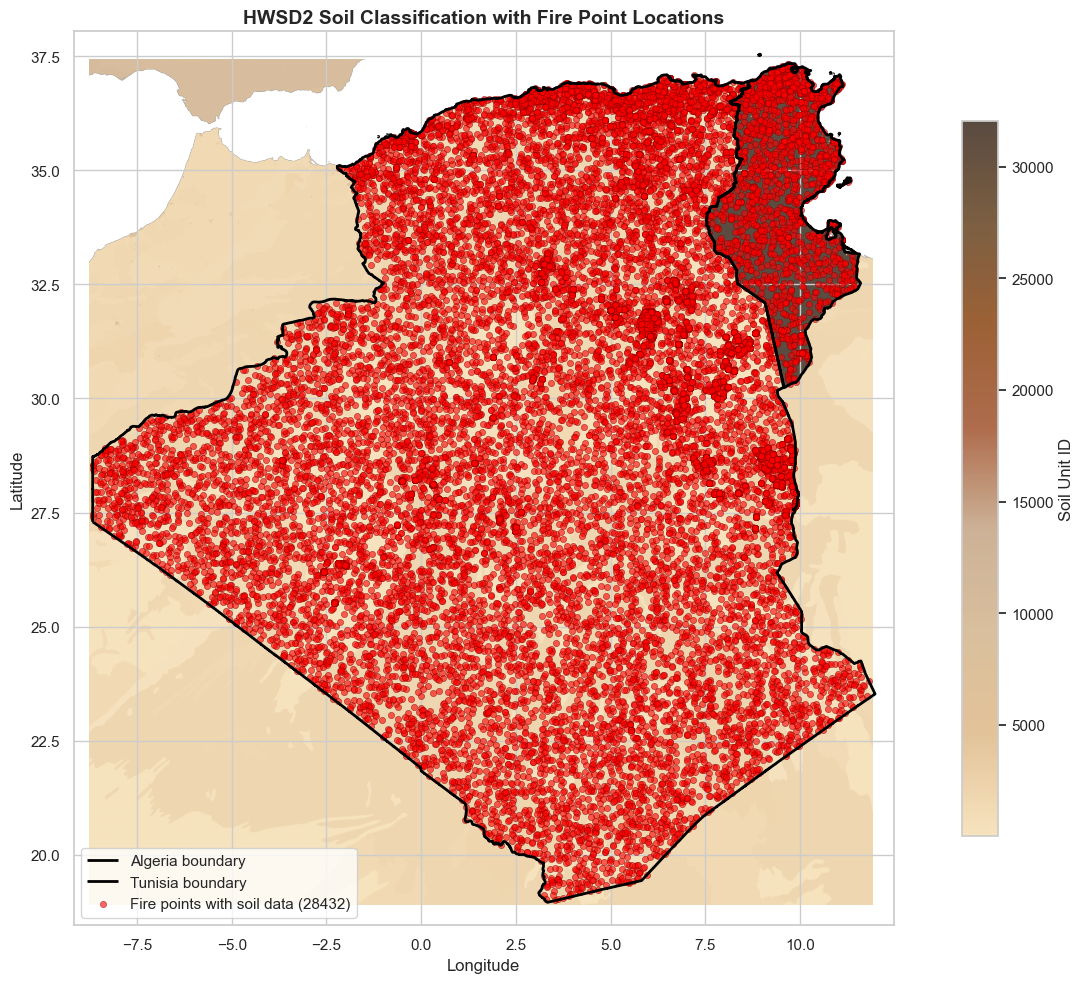

✓ Visualization complete!


In [11]:
from rasterio.plot import plotting_extent
from matplotlib.colors import LinearSegmentedColormap
# Load country boundaries using config paths
algeria_boundary = gpd.read_file(ALGERIA_SHP)
tunisia_boundary = gpd.read_file(TUNISIA_SHP)

fig, ax = plt.subplots(figsize=(14, 10))

# Plot clipped raster with realistic soil colors
band1 = clipped_array[0].astype('float32')
nodata = clipped_profile.get('nodata')
if nodata is not None:
    band1[band1 == nodata] = np.nan

# Create a realistic soil colormap (earth tones)
soil_colors = [
    '#F5DEB3',  # Wheat (light sandy soil)
    '#DEB887',  # Burlywood (sandy loam)
    '#D2B48C',  # Tan (loam)
    '#C4A484',  # Light brown (silt loam)
    '#A0522D',  # Sienna (clay loam)
    '#8B4513',  # Saddle brown (clay)
    '#654321',  # Dark brown (organic rich)
    '#3D2B1F',  # Bistre (dark organic)
]
soil_cmap = LinearSegmentedColormap.from_list('soil', soil_colors, N=256)

extent = plotting_extent(band1, transform=new_transform)
im = ax.imshow(band1, cmap=soil_cmap, extent=extent, origin='upper', alpha=0.85)

# Dissolve to get country outlines
algeria_outline = algeria_boundary.dissolve().boundary
tunisia_outline = tunisia_boundary.dissolve().boundary

# Plot country boundaries
algeria_outline.plot(ax=ax, color='black', linewidth=2, label='Algeria boundary')
tunisia_outline.plot(ax=ax, color='black', linewidth=2, label='Tunisia boundary')

# Overlay fire points
fires_with_soil = fires_df[fires_df['soil_unit_id'].notna()]
fires_without_soil = fires_df[fires_df['soil_unit_id'].isna()]

ax.scatter(fires_with_soil['longitude'], fires_with_soil['latitude'], 
           c='red', s=20, alpha=0.6, edgecolors='darkred', linewidth=0.5,
           label=f'Fire points with soil data ({len(fires_with_soil)})')

if len(fires_without_soil) > 0:
    ax.scatter(fires_without_soil['longitude'], fires_without_soil['latitude'], 
               c='orange', s=20, alpha=0.6, marker='x',
               label=f'Fire points without soil data ({len(fires_without_soil)})')

# Set axis limits to show only Algeria and Tunisia
combined_bounds = gpd.GeoDataFrame(pd.concat([algeria_boundary, tunisia_boundary])).total_bounds
ax.set_xlim(combined_bounds[0] - 0.5, combined_bounds[2] + 0.5)
ax.set_ylim(combined_bounds[1] - 0.5, combined_bounds[3] + 0.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('HWSD2 Soil Classification with Fire Point Locations', fontsize=14, fontweight='bold')
ax.legend(loc='lower left')
fig.colorbar(im, ax=ax, label='Soil Unit ID', shrink=0.8)
plt.tight_layout()
plt.show()

print(f"✓ Visualization complete!")


---
## Section 3: Exploratory Data Analysis

Perform comprehensive analysis on the **raw soil data** before preprocessing.

### 3.1 Descriptive Statistics

In [12]:
# Import scipy for Q-Q plots
import scipy.stats as stats

# Define helper function for descriptive statistics
def descriptive_stats_df(df):
    """
    Return enhanced descriptive statistics for a numeric DataFrame.
    Includes: count, mean, std, min, 25%, 50%, 75%, max, missing, unique, skew, kurtosis
    """
    numeric_df = df.select_dtypes(include=[np.number])
    desc = numeric_df.describe().T
    desc['missing'] = numeric_df.isnull().sum()
    desc['unique'] = numeric_df.nunique(dropna=True)
    desc['skew'] = numeric_df.skew(numeric_only=True)
    desc['kurtosis'] = numeric_df.kurtosis(numeric_only=True)
    
    # Reorder columns
    cols_order = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 
                  'missing', 'unique', 'skew', 'kurtosis']
    cols = [c for c in cols_order if c in desc.columns]
    return desc[cols]

# Compute descriptive statistics on RAW data
print("="*60)
print("DESCRIPTIVE STATISTICS - RAW SOIL DATA")
print("="*60)
desc_stats = descriptive_stats_df(df_soil)
print(desc_stats)
print("\n✓ Statistics computed successfully!")
print("="*60)

DESCRIPTIVE STATISTICS - RAW SOIL DATA
                count       mean        std   min     25%     50%    75%  \
COARSE        58405.0  11.184573   8.437106 -9.00   4.000  10.000  18.00   
SAND          58405.0  46.051879  17.348953 -9.00  36.000  43.000  55.00   
SILT          58405.0  30.209023  11.973649 -9.00  23.000  31.000  38.00   
CLAY          58405.0  21.282664  10.549217 -9.00  16.000  20.000  27.00   
TEXTURE_USDA  57116.0   8.602581   2.500621  3.00   7.000   9.000  11.00   
BULK          58405.0   1.226432   0.863178 -9.00   1.290   1.370   1.46   
REF_BULK      57116.0   1.707009   0.161498  0.97   1.650   1.710   1.81   
ORG_CARBON    57733.0   2.706419   6.243177 -9.00   0.711   1.316   2.20   
PH_WATER      58405.0   6.396850   1.924548 -9.00   5.700   6.600   7.70   
TOTAL_N       58405.0   1.720019   2.559947 -9.00   0.800   1.140   1.78   
CN_RATIO      58405.0  11.511412   3.993419 -9.00  10.000  11.000  12.00   
CEC_SOIL      58405.0  17.711720  14.348210 -9.00

### 3.2 Univariate Analysis (Boxplots)

UNIVARIATE ANALYSIS - BOXPLOTS

Analyzing 21 numeric columns with boxplots...


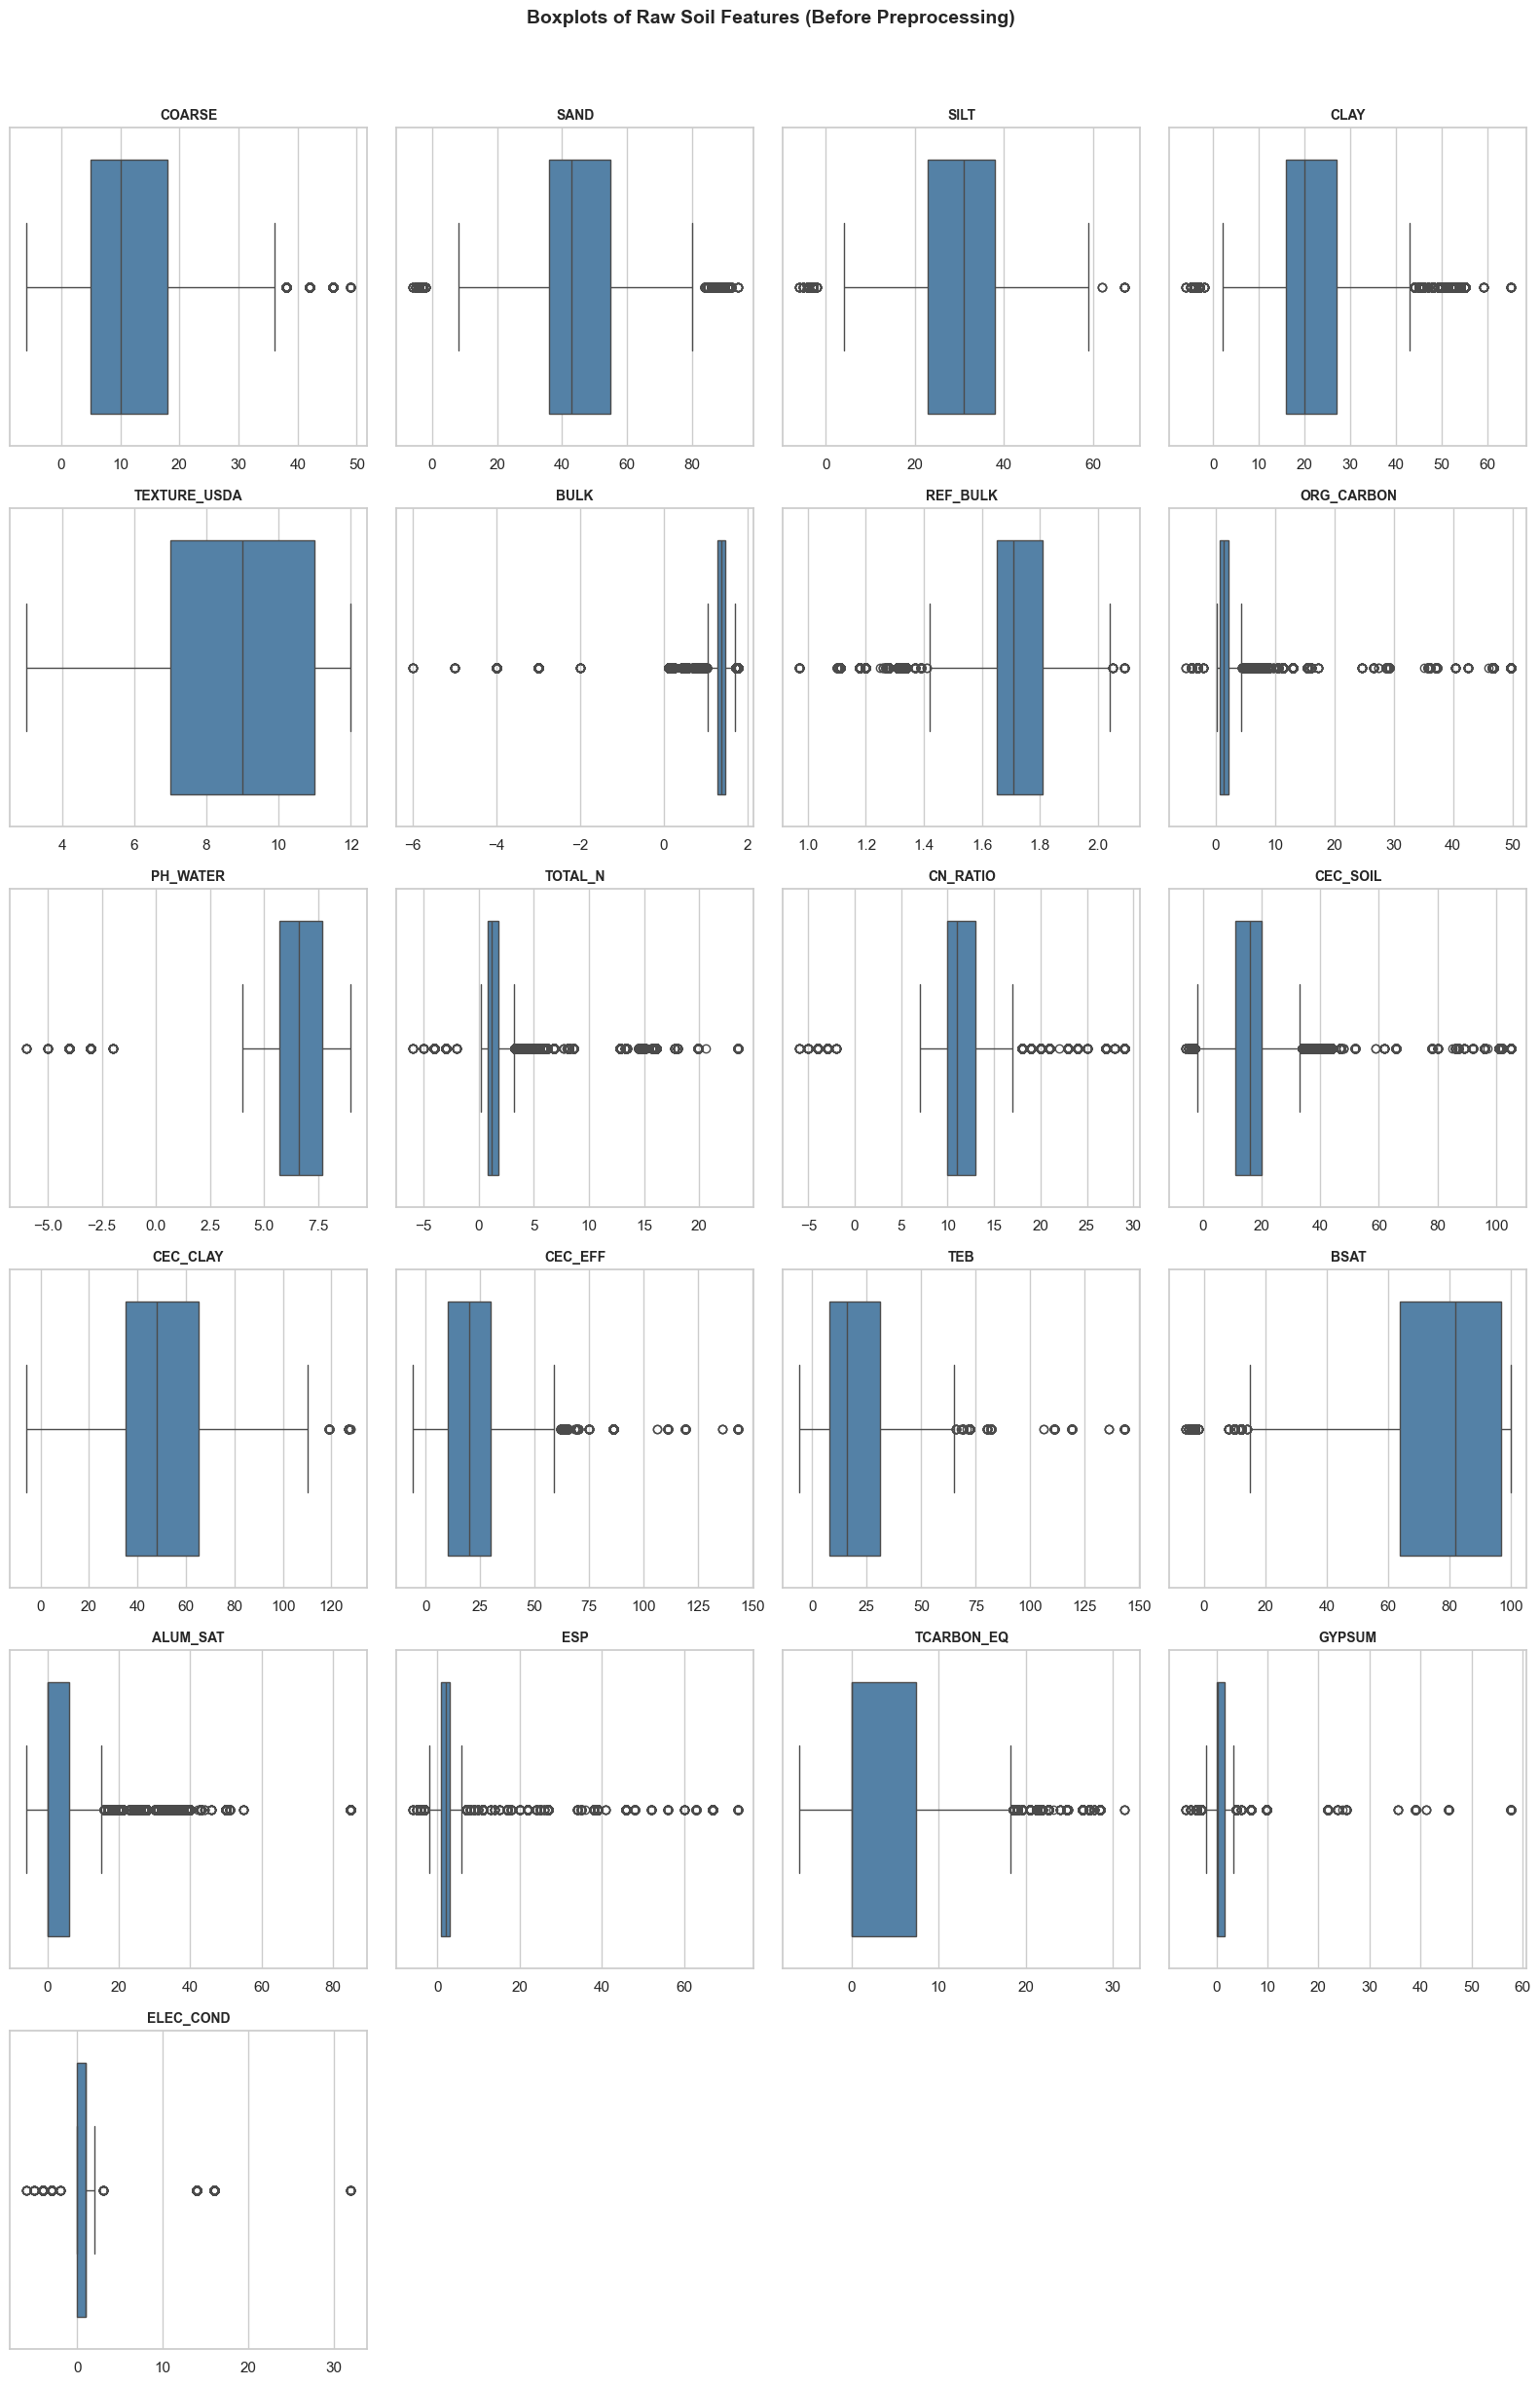


✓ Boxplots generated for all numeric features!
  Note: Sentinel values (-9, -1, -99, -999) excluded from visualization


In [13]:
print("="*60)
print("UNIVARIATE ANALYSIS - BOXPLOTS")
print("="*60)

# Get numeric columns from raw data
numeric_cols = df_soil.select_dtypes(include=[np.number]).columns
print(f"\nAnalyzing {len(numeric_cols)} numeric columns with boxplots...")

# Create boxplots for all numeric features
n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    # Filter out sentinel values for visualization
    data = df_soil[col].replace([-9, -1, -99, -999], np.nan).dropna()
    if len(data) > 0:
        sns.boxplot(x=data, ax=ax, color='steelblue')
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.set_xlabel('')
    else:
        ax.set_visible(False)

# Hide empty subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots of Raw Soil Features (Before Preprocessing)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Boxplots generated for all numeric features!")
print("  Note: Sentinel values (-9, -1, -99, -999) excluded from visualization")
print("="*60)

### 3.3 Bivariate Analysis

In [14]:
# Load fire point locations
fires_df = pd.read_csv(FIRES_WITH_ARTIFICIAL_UNSUPERVISED)

fires_df_original = fires_df.copy()  # Keep original for comparison

print(f"✓ Loaded {len(fires_df)} fire points from: {FIRES_WITH_ARTIFICIAL_UNSUPERVISED}")
print(f"  Columns: {list(fires_df.columns)}")
print(f"\n📊 Class Distribution:")
print(fires_df['class'].value_counts())

# Convert to GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326'
)

print(f"\n✓ GeoDataFrame created")
print(f"  CRS: {fires_gdf.crs}")
print(f"  Bounds: [{fires_df['longitude'].min():.2f}, {fires_df['latitude'].min():.2f}] → [{fires_df['longitude'].max():.2f}, {fires_df['latitude'].max():.2f}]")


✓ Loaded 28432 fire points from: C:\Users\Azur\Downloads\TP\DM\results\data\fires_with_artificial_unsupervised.csv
  Columns: ['longitude', 'latitude', 'class']

📊 Class Distribution:
class
1    14216
0    14216
Name: count, dtype: int64

✓ GeoDataFrame created
  CRS: EPSG:4326
  Bounds: [-8.67, 19.01] → [11.82, 37.32]


BIVARIATE ANALYSIS - SCATTER PLOTS

Top 10 correlated pairs:
  CEC_EFF vs TEB: r = 0.947
  ORG_CARBON vs TOTAL_N: r = 0.924
  CLAY vs REF_BULK: r = 0.924
  TOTAL_N vs CEC_SOIL: r = 0.883
  ORG_CARBON vs CEC_SOIL: r = 0.872
  CLAY vs TEXTURE_USDA: r = -0.861
  PH_WATER vs BSAT: r = 0.813
  ESP vs ELEC_COND: r = 0.800
  BULK vs PH_WATER: r = 0.799
  SAND vs TEXTURE_USDA: r = 0.793

Generating scatter plots for top correlated pairs...


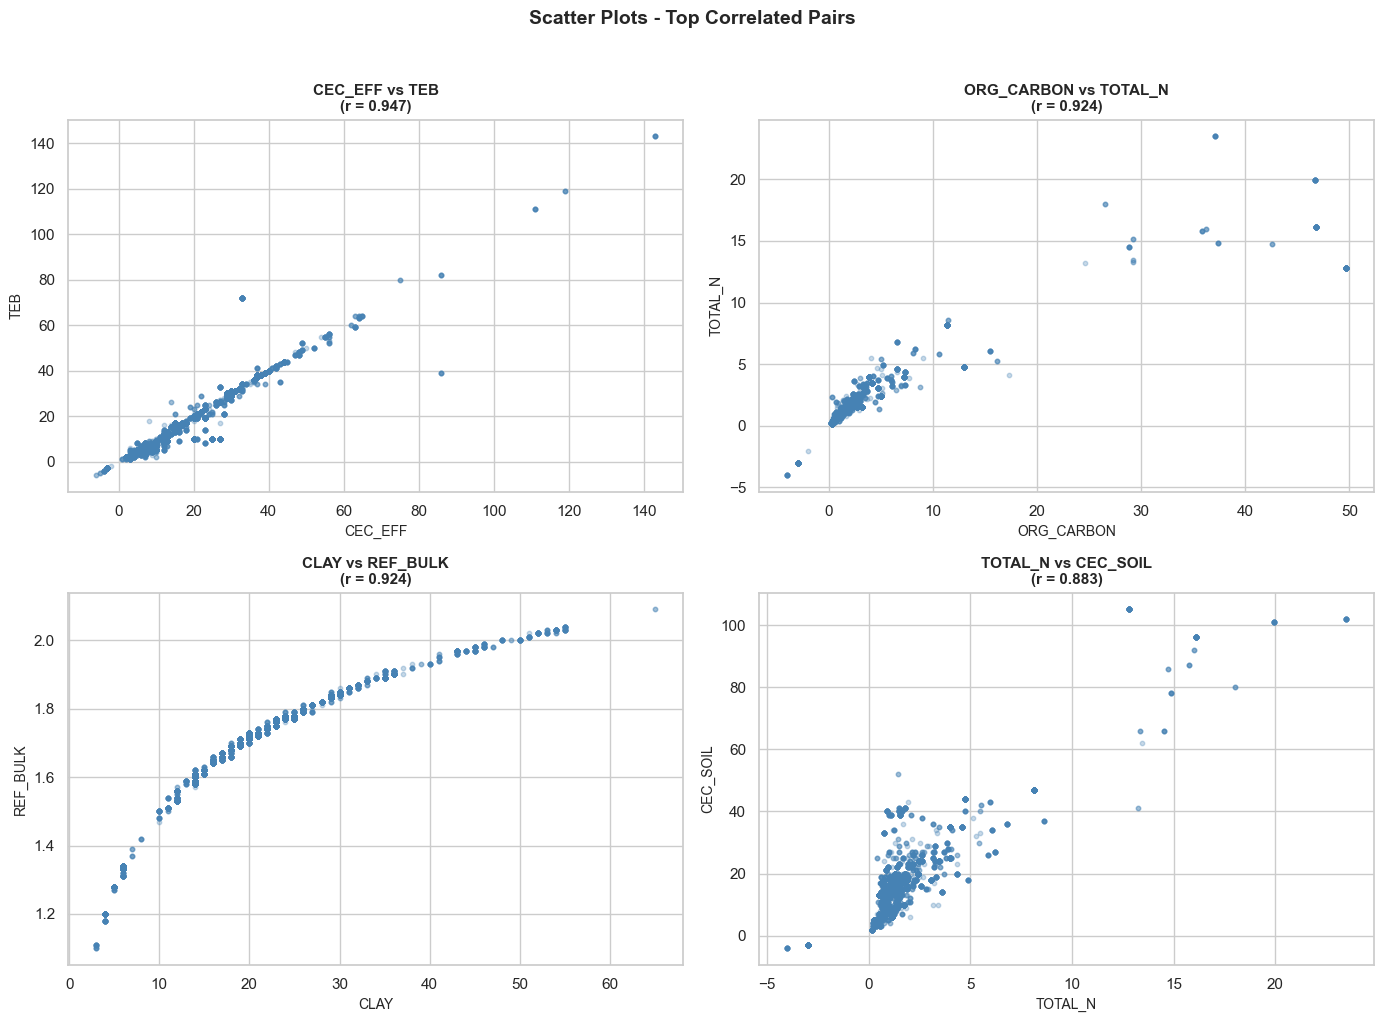


✓ Scatter plots generated!


In [15]:
print("="*60)
print("BIVARIATE ANALYSIS - SCATTER PLOTS")
print("="*60)

# First, compute correlation matrix and get top correlated pairs
numeric_df = df_soil.select_dtypes(include=[np.number]).copy()
# Replace sentinel values with NaN for correlation analysis
numeric_df = numeric_df.replace([-9, -1, -99, -999], np.nan)

corr_matrix = numeric_df.corr()

# Get top correlated pairs (excluding self-correlations)
corr_pairs = []
for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if i < j:  # Only upper triangle
            corr_val = corr_matrix.loc[col1, col2]
            if not np.isnan(corr_val):
                corr_pairs.append((col1, col2, corr_val, abs(corr_val)))

# Sort by absolute correlation (descending)
corr_pairs.sort(key=lambda x: x[3], reverse=True)

print(f"\nTop 10 correlated pairs:")
for col1, col2, corr_val, _ in corr_pairs[:10]:
    print(f"  {col1} vs {col2}: r = {corr_val:.3f}")

# Plot scatter plots for top 4 correlated pairs
print("\nGenerating scatter plots for top correlated pairs...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (col1, col2, corr_val, _) in enumerate(corr_pairs[:4]):
    ax = axes[idx]
    # Get clean data for both columns
    mask = numeric_df[[col1, col2]].notna().all(axis=1)
    x_data = numeric_df.loc[mask, col1]
    y_data = numeric_df.loc[mask, col2]
    
    # Sample if too many points
    if len(x_data) > 5000:
        sample_idx = np.random.choice(len(x_data), 5000, replace=False)
        x_data = x_data.iloc[sample_idx]
        y_data = y_data.iloc[sample_idx]
    
    ax.scatter(x_data, y_data, alpha=0.3, s=10, c='steelblue')
    ax.set_xlabel(col1, fontsize=10)
    ax.set_ylabel(col2, fontsize=10)
    ax.set_title(f'{col1} vs {col2}\n(r = {corr_val:.3f})', fontsize=11, fontweight='bold')

plt.suptitle('Scatter Plots - Top Correlated Pairs', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Scatter plots generated!")
print("="*60)

BIVARIATE ANALYSIS - Q-Q PLOTS

Generating Q-Q plots to assess normality of distributions...


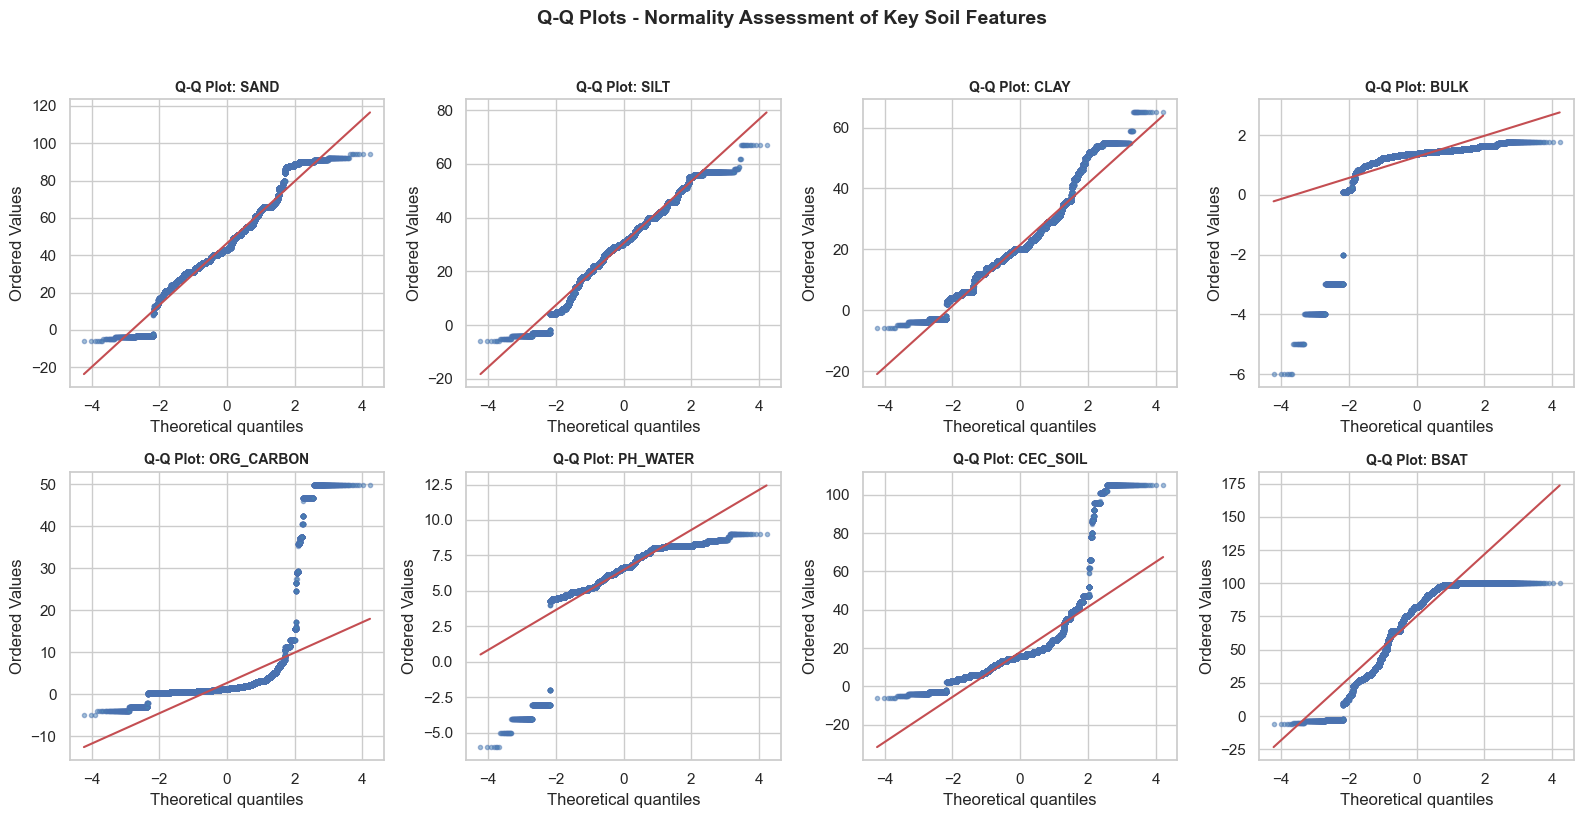


✓ Q-Q plots generated!
  Interpretation: Points following the diagonal line indicate normal distribution
  Deviations from the line indicate non-normality (skewness, heavy tails, etc.)


In [16]:
print("="*60)
print("BIVARIATE ANALYSIS - Q-Q PLOTS")
print("="*60)

# Q-Q plots to check normality of numeric features
print("\nGenerating Q-Q plots to assess normality of distributions...")

# Select a subset of key features for Q-Q plots
key_features = ['SAND', 'SILT', 'CLAY', 'BULK', 'ORG_CARBON', 'PH_WATER', 'CEC_SOIL', 'BSAT']
available_features = [f for f in key_features if f in numeric_df.columns]

n_features = len(available_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(available_features):
    ax = axes[idx]
    data = numeric_df[col].dropna()
    if len(data) > 0:
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot: {col}', fontsize=10, fontweight='bold')
        ax.get_lines()[0].set_markerfacecolor('steelblue')
        ax.get_lines()[0].set_alpha(0.5)
        ax.get_lines()[0].set_markersize(3)

# Hide empty subplots
for idx in range(len(available_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Q-Q Plots - Normality Assessment of Key Soil Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ Q-Q plots generated!")
print("  Interpretation: Points following the diagonal line indicate normal distribution")
print("  Deviations from the line indicate non-normality (skewness, heavy tails, etc.)")
print("="*60)

### 3.4 Categorical Variable Analysis (Bar Plots)

CATEGORICAL VARIABLE ANALYSIS - BAR PLOTS

Distribution of TEXTURE_USDA

Value counts:
TEXTURE_USDA
9.0     21935
11.0    13373
5.0      8570
3.0      3623
12.0     3230
10.0     3184
7.0      2976
8.0       194
4.0        31
Name: count, dtype: int64


C:\Users\Azur\AppData\Local\Temp\ipykernel_21944\3677788262.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')


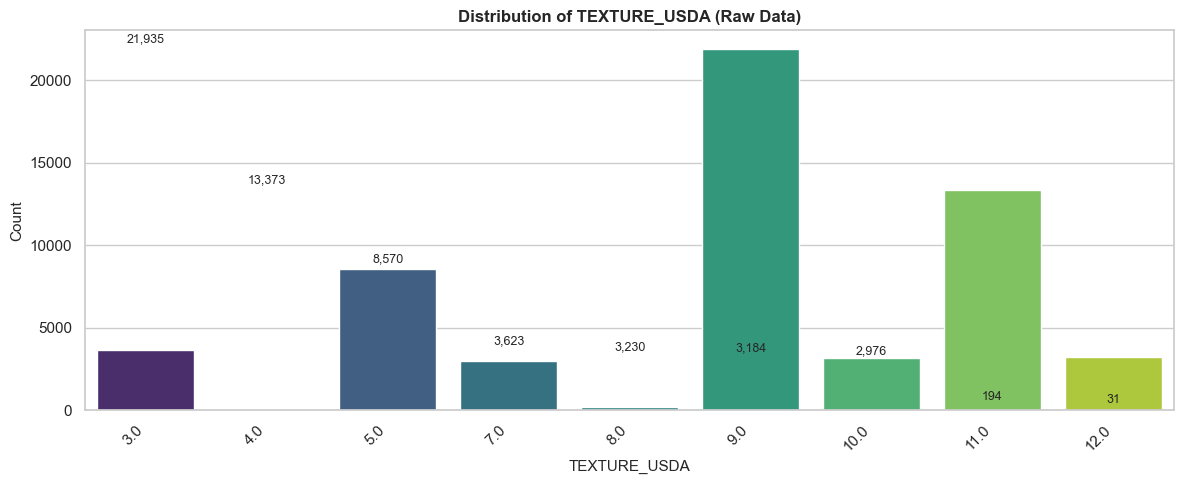

C:\Users\Azur\AppData\Local\Temp\ipykernel_21944\3677788262.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')



Summary:
  Total records: 58,405
  Unique categories: 9
  Most common: 9.0 (21,935 records, 37.6%)
  Least common: 4.0 (31 records, 0.1%)

Distribution of TEXTURE_SOTER

Value counts:
TEXTURE_SOTER
M    43216
C     8007
F     5869
-     1289
V       24
Name: count, dtype: int64


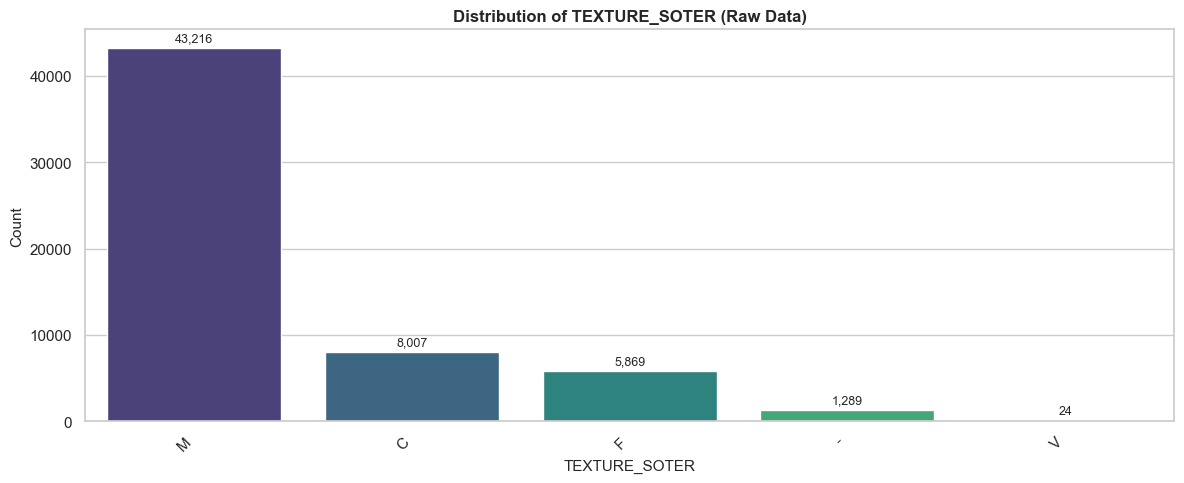


Summary:
  Total records: 58,405
  Unique categories: 5
  Most common: M (43,216 records, 74.0%)
  Least common: V (24 records, 0.0%)

✓ Categorical analysis complete!


In [17]:
print("="*60)
print("CATEGORICAL VARIABLE ANALYSIS - BAR PLOTS")
print("="*60)

# Identify categorical columns in the soil dataset
categorical_cols = ['TEXTURE_USDA', 'TEXTURE_SOTER']

for col in categorical_cols:
    if col in df_soil.columns:
        print(f"\n{'='*50}")
        print(f"Distribution of {col}")
        print(f"{'='*50}")
        
        # Get value counts
        value_counts = df_soil[col].value_counts()
        print(f"\nValue counts:")
        print(value_counts)
        
        # Create bar plot
        plt.figure(figsize=(12, 5))
        
        # Main bar plot
        ax = sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis')
        
        # Add count labels on bars
        for i, (idx, val) in enumerate(zip(value_counts.index, value_counts.values)):
            ax.text(i, val + max(value_counts.values)*0.01, f'{val:,}', 
                   ha='center', va='bottom', fontsize=9)
        
        plt.title(f'Distribution of {col} (Raw Data)', fontsize=12, fontweight='bold')
        plt.xlabel(col, fontsize=11)
        plt.ylabel('Count', fontsize=11)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print(f"\nSummary:")
        print(f"  Total records: {len(df_soil):,}")
        print(f"  Unique categories: {df_soil[col].nunique()}")
        print(f"  Most common: {value_counts.index[0]} ({value_counts.iloc[0]:,} records, {value_counts.iloc[0]/len(df_soil)*100:.1f}%)")
        if len(value_counts) > 1:
            print(f"  Least common: {value_counts.index[-1]} ({value_counts.iloc[-1]:,} records, {value_counts.iloc[-1]/len(df_soil)*100:.1f}%)")

print("\n" + "="*60)
print("✓ Categorical analysis complete!")
print("="*60)

---
## Section 4: Data Preprocessing

Clean and prepare the soil data for analysis and modeling.

In [18]:
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

print("\nBefore preprocessing:")
print(f"  Shape: {df_soil.shape}")
print(f"  Missing values: {df_soil.isnull().sum().sum()}")
print(f"  Note: Duplicate property combinations exist by design")
print(f"        (same properties, different geographic units)")
print(f"  Duplicates will NOT be dropped to maintain spatial linkage")

# Define preprocessing function
def preprocess_soil_df(df):
    """
    Comprehensive cleaning for HWSD soil dataframe:
    1. Keep all rows (duplicates are by design - same properties, different spatial units)
    2. Replace sentinel values with NaN
    3. Impute missing values (median for numeric, mode for categorical, interpolation for dates)
    4. Detect and replace outliers using IQR method
    5. Normalize numeric features using StandardScaler (z-score normalization)
    
    Note: We DO NOT drop duplicates because:
    - Each row has a unique ID linking to different geographic locations
    - Multiple spatial units can share the same soil properties
    - Dropping duplicates would break the spatial linkage
    """
    dfc = df.copy()
    
    print("\n--- Step 1: Keep All Rows (No Duplicate Removal) ---")
    print(f"  Total rows: {len(dfc):,}")
    print(f"  Unique property combinations: {dfc.drop_duplicates().shape[0]:,}")
    print(f"  Reason: Multiple geographic units share same soil properties")
    print(f"  ✓ All rows retained for proper spatial linkage")
    
    print("\n--- Step 2: Replace Sentinel Values ---")
    # Replace common sentinels with NaN
    sentinels = [-9, -1, -99, -999, '-9', '-1', '-99', '-999', '-', ' - ', 'None']
    sentinel_count = 0
    for col in dfc.columns:
        before_sentinel = dfc[col].isnull().sum()
        dfc[col] = dfc[col].replace(sentinels, np.nan)
        after_sentinel = dfc[col].isnull().sum()
        sentinel_count += (after_sentinel - before_sentinel)
    print(f"  Replaced {sentinel_count} sentinel values with NaN")
    
    # Clean object columns
    for col in dfc.select_dtypes(include=['object']).columns:
        dfc[col] = dfc[col].astype(str).str.strip()
        dfc[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan}, inplace=True)
    
    # Convert to numeric where possible
    for col in dfc.columns:
        if dfc[col].dtype == 'object':
            dfc[col] = pd.to_numeric(dfc[col], errors='ignore')
    
    print("\n--- Step 3: Impute Missing Values ---")
    # Separate column types
    numeric_cols = dfc.select_dtypes(include=[np.number]).columns
    categorical_cols = dfc.select_dtypes(include=['object', 'category']).columns
    date_cols = dfc.select_dtypes(include=['datetime64']).columns
    
    # Impute numeric columns with median
    print(f"  Numeric columns ({len(numeric_cols)}):")
    for col in numeric_cols:
        missing_before = dfc[col].isnull().sum()
        if missing_before > 0:
            median_val = dfc[col].median()
            if not np.isnan(median_val):
                dfc[col] = dfc[col].fillna(median_val)
                print(f"    {col}: {missing_before} missing → filled with median ({median_val:.2f})")
    
    # Impute categorical columns with mode
    print(f"  Categorical columns ({len(categorical_cols)}):")
    for col in categorical_cols:
        missing_before = dfc[col].isnull().sum()
        if missing_before > 0:
            mode_series = dfc[col].mode(dropna=True)
            if not mode_series.empty:
                dfc[col] = dfc[col].fillna(mode_series.iloc[0])
                print(f"    {col}: {missing_before} missing → filled with mode ({mode_series.iloc[0]})")
    
    # Impute date columns with interpolation
    if len(date_cols) > 0:
        print(f"  Date columns ({len(date_cols)}):")
        for col in date_cols:
            missing_before = dfc[col].isnull().sum()
            if missing_before > 0:
                dfc[col] = dfc[col].interpolate(method='time')
                print(f"    {col}: {missing_before} missing → interpolated")
    
    print("\n--- Step 4: Detect and Replace Outliers (IQR Method) ---")
    outlier_counts = {}
    for col in numeric_cols:
        Q1 = dfc[col].quantile(0.25)
        Q3 = dfc[col].quantile(0.75)
        IQR = Q3 - Q1
        
        if IQR == 0:  # Skip if no variance
            continue
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers
        outliers = (dfc[col] < lower_bound) | (dfc[col] > upper_bound)
        outlier_count = outliers.sum()
        
        if outlier_count > 0:
            # Replace outliers with median
            median_val = dfc[col].median()
            dfc.loc[outliers, col] = median_val
            outlier_counts[col] = outlier_count
            print(f"  {col}: {outlier_count} outliers ({outlier_count/len(dfc)*100:.2f}%) → replaced with median ({median_val:.2f})")
    
    if not outlier_counts:
        print("  No outliers detected")
    
    # Drop rows that are entirely NaN (if any remain)
    before_empty = len(dfc)
    dfc.dropna(how='all', inplace=True)
    dropped_empty = before_empty - len(dfc)
    if dropped_empty > 0:
        print(f"\n--- Dropped {dropped_empty} completely empty rows ---")
    
    print("\n--- Step 5: Normalize Numeric Features ---")
    # Import StandardScaler
    from sklearn.preprocessing import StandardScaler
    
    # Get numeric columns (excluding categorical)
    numeric_cols = dfc.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = dfc.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if len(numeric_cols) > 0:
        # Initialize scaler
        scaler = StandardScaler()
        
        # Fit and transform numeric columns
        dfc[numeric_cols] = scaler.fit_transform(dfc[numeric_cols])
        
        print(f"  ✓ Normalized {len(numeric_cols)} numeric features using StandardScaler (z-score)")
        print(f"    Method: (x - mean) / std")
        print(f"    Result: Mean ≈ 0, Std ≈ 1 for all numeric features")
        
        # Show example stats after normalization
        print(f"\n  Sample normalized statistics:")
        sample_cols = numeric_cols[:3]
        for col in sample_cols:
            print(f"    {col}: mean={dfc[col].mean():.4f}, std={dfc[col].std():.4f}")
    else:
        print("  No numeric columns to normalize")
    
    if len(categorical_cols) > 0:
        print(f"\n  ℹ Categorical features ({len(categorical_cols)}) not normalized:")
        print(f"    {', '.join(categorical_cols)}")
    
    return dfc

# Apply preprocessing
soil_data_clean = preprocess_soil_df(df_soil)

print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"Before: {df_soil.shape[0]:,} rows, {df_soil.isnull().sum().sum():,} missing values")
print(f"After:  {soil_data_clean.shape[0]:,} rows, {soil_data_clean.isnull().sum().sum():,} missing values")
print(f"Rows removed: {len(df_soil) - len(soil_data_clean):,}")
print(f"\n✓ All rows retained (duplicates kept for spatial linkage)")
print(f"✓ {soil_data_clean.drop_duplicates().shape[0]:,} unique property combinations")
print(f"✓ Preprocessing complete: cleaned values, no data loss!")
print("="*60)

DATA PREPROCESSING

Before preprocessing:
  Shape: (58405, 22)
  Missing values: 3250
  Note: Duplicate property combinations exist by design
        (same properties, different geographic units)
  Duplicates will NOT be dropped to maintain spatial linkage

--- Step 1: Keep All Rows (No Duplicate Removal) ---
  Total rows: 58,405
  Unique property combinations: 578
  Reason: Multiple geographic units share same soil properties
  ✓ All rows retained for proper spatial linkage

--- Step 2: Replace Sentinel Values ---
  Replaced 9077 sentinel values with NaN

--- Step 3: Impute Missing Values ---
  Numeric columns (21):
    COARSE: 429 missing → filled with median (10.00)
    SAND: 429 missing → filled with median (43.00)
    SILT: 429 missing → filled with median (31.00)
    CLAY: 429 missing → filled with median (20.00)
    TEXTURE_USDA: 1289 missing → filled with median (9.00)
    BULK: 429 missing → filled with median (1.38)
    REF_BULK: 1289 missing → filled with median (1.71)
    O

C:\Users\Azur\AppData\Local\Temp\ipykernel_21944\4235913916.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfc[col].replace({'nan': np.nan, 'None': np.nan, '': np.nan}, inplace=True)
C:\Users\Azur\AppData\Local\Temp\ipykernel_21944\4235913916.py:54: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfc[col] = pd.to_numeric(dfc[col], errors='ignore')


### 4.1 Diagnose Data Loss Issue

In [19]:
print("="*60)
print("DATA LOSS DIAGNOSTIC")
print("="*60)

print(f"\nOriginal dataset: {df_soil.shape}")
print(f"Total records: {len(df_soil):,}")

# Step 1: Check for duplicates
print("\n--- Step 1: Duplicate Analysis ---")
duplicates = df_soil.duplicated()
duplicate_count = duplicates.sum()
print(f"Duplicate rows: {duplicate_count:,} ({duplicate_count/len(df_soil)*100:.2f}%)")
print(f"Unique rows: {len(df_soil) - duplicate_count:,}")

# Check if we're dropping duplicates correctly
df_no_dup = df_soil.drop_duplicates()
print(f"After dropping duplicates: {len(df_no_dup):,} rows remaining")

# Step 2: Analyze what makes rows "unique"
print("\n--- Step 2: Data Uniqueness Analysis ---")
print("\nChecking column-by-column uniqueness:")
for col in df_soil.columns[:5]:  # Check first 5 columns
    unique_vals = df_soil[col].nunique()
    print(f"  {col}: {unique_vals:,} unique values (out of {len(df_soil):,})")

# Check if all rows are identical
print("\n--- Step 3: Identical Rows Check ---")
print("First 10 rows of original data:")
print(df_soil.head(10))

print("\n--- Step 4: Sentinel Values Impact ---")
sentinels = [-9, -1, -99, -999]
df_test = df_soil.copy()

# Count sentinel values per column
print("\nSentinel values per column:")
for col in df_soil.select_dtypes(include=[np.number]).columns[:5]:
    sentinel_count = df_soil[col].isin(sentinels).sum()
    if sentinel_count > 0:
        print(f"  {col}: {sentinel_count:,} sentinel values ({sentinel_count/len(df_soil)*100:.2f}%)")

# Replace sentinels and check again
for col in df_test.columns:
    df_test[col] = df_test[col].replace(sentinels, np.nan)

print(f"\nAfter replacing sentinels with NaN:")
print(f"  Missing values: {df_test.isnull().sum().sum():,}")
print(f"  Rows with ANY missing value: {df_test.isnull().any(axis=1).sum():,}")
print(f"  Rows with ALL values missing: {df_test.isnull().all(axis=1).sum():,}")

# Step 5: Check if many rows become identical after sentinel replacement
df_test_filled = df_test.copy()
for col in df_test_filled.select_dtypes(include=[np.number]).columns:
    df_test_filled[col] = df_test_filled[col].fillna(df_test_filled[col].median())

duplicates_after_impute = df_test_filled.duplicated().sum()
print(f"\n--- Step 5: Duplicates After Imputation ---")
print(f"Duplicates after median imputation: {duplicates_after_impute:,}")
print(f"Unique rows after imputation: {len(df_test_filled) - duplicates_after_impute:,}")

print("\n" + "="*60)
print("DIAGNOSIS COMPLETE")
print("="*60)

DATA LOSS DIAGNOSTIC

Original dataset: (58405, 22)
Total records: 58,405

--- Step 1: Duplicate Analysis ---
Duplicate rows: 57,827 (99.01%)
Unique rows: 578
After dropping duplicates: 578 rows remaining

--- Step 2: Data Uniqueness Analysis ---

Checking column-by-column uniqueness:
  COARSE: 44 unique values (out of 58,405)
  SAND: 86 unique values (out of 58,405)
  SILT: 65 unique values (out of 58,405)
  CLAY: 63 unique values (out of 58,405)
  TEXTURE_USDA: 9 unique values (out of 58,405)

--- Step 3: Identical Rows Check ---
First 10 rows of original data:
     COARSE  SAND  SILT  CLAY  TEXTURE_USDA TEXTURE_SOTER  BULK  REF_BULK  \
666       5    67    18    15          11.0             C  1.35      1.63   
667       5    67    18    15          11.0             C  1.35      1.63   
668       5    67    18    15          11.0             C  1.35      1.63   
669       5    67    18    15          11.0             C  1.35      1.63   
694       2    24    52    24           7.0  

In [20]:
print("="*60)
print("POST-PREPROCESSING VALIDATION")
print("="*60)

# 1. Check for remaining missing values
print("\n1. Missing Values Check:")
missing = soil_data_clean.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values remaining")
else:
    print(f"   ⚠ {missing.sum()} missing values found:")
    print(missing[missing > 0])

# 2. Check data ranges
print("\n2. Data Range Validation:")
numeric_cols = soil_data_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols[:5]:  # Check first 5
    print(f"   {col}: [{soil_data_clean[col].min():.2f}, {soil_data_clean[col].max():.2f}]")

# 3. Check distributions before/after
print("\n3. Distribution Comparison:")
print(f"   Original shape: {df_soil.shape}")
print(f"   Cleaned shape: {soil_data_clean.shape}")
print(f"   Rows removed: {len(df_soil) - len(soil_data_clean)}")

# 4. Summary statistics
print("\n4. Summary Statistics (cleaned data):")
print(soil_data_clean.describe().T[['mean', 'std', 'min', 'max']])

print("\n✓ Validation complete!")
print("="*60)

POST-PREPROCESSING VALIDATION

1. Missing Values Check:
   ✓ No missing values remaining

2. Data Range Validation:
   COARSE: [-2.30, 3.47]
   SAND: [-2.88, 2.72]
   SILT: [-2.50, 2.59]
   CLAY: [-2.42, 2.97]
   TEXTURE_USDA: [-2.27, 1.37]

3. Distribution Comparison:
   Original shape: (58405, 22)
   Cleaned shape: (58405, 22)
   Rows removed: 0

4. Summary Statistics (cleaned data):
                      mean       std       min       max
COARSE       -7.007493e-17  1.000009 -2.298100  3.466503
SAND          6.910166e-17  1.000009 -2.883000  2.717322
SILT         -1.654547e-17  1.000009 -2.495122  2.594037
CLAY         -1.674012e-16  1.000009 -2.424789  2.970953
TEXTURE_USDA -7.299472e-17  1.000009 -2.268551  1.369959
BULK         -1.294440e-16  1.000009 -3.060737  2.823222
REF_BULK     -4.095004e-16  1.000009 -2.855366  2.751883
ORG_CARBON   -4.866314e-17  1.000009 -1.489855  3.581559
PH_WATER      2.919789e-16  1.000009 -2.358734  2.132971
TOTAL_N      -1.674012e-16  1.000009 -1.8

### 4.2 Feature Normalization Analysis

Analyze which features require normalization based on their scales and distributions.

In [21]:
print("="*60)
print("FEATURE NORMALIZATION ANALYSIS")
print("="*60)

# Analyze each feature to determine if normalization is needed
print("\nAnalyzing 22 soil features for normalization requirements...\n")

# Get feature information
feature_info = []

for col in soil_data_clean.columns:
    dtype = soil_data_clean[col].dtype
    
    if dtype == 'object' or dtype.name == 'category':
        # Categorical features - no normalization needed
        unique_vals = soil_data_clean[col].nunique()
        feature_info.append({
            'Feature': col,
            'Type': 'Categorical',
            'Min': '-',
            'Max': '-',
            'Range': '-',
            'Scale': f'{unique_vals} categories',
            'Normalize': 'NO',
            'Reason': 'Categorical variable'
        })
    else:
        # Numeric features - check if normalization needed
        min_val = soil_data_clean[col].min()
        max_val = soil_data_clean[col].max()
        value_range = max_val - min_val
        mean_val = soil_data_clean[col].mean()
        std_val = soil_data_clean[col].std()
        
        # Determine if normalization is needed based on:
        # 1. Scale differences (range > 100 suggests large scale)
        # 2. Different units/scales between features
        
        if value_range > 100:
            normalize = 'YES'
            reason = f'Large scale (range: {value_range:.1f})'
        elif value_range > 10:
            normalize = 'YES'
            reason = f'Medium scale (range: {value_range:.1f})'
        else:
            normalize = 'MAYBE'
            reason = f'Small scale (range: {value_range:.1f}), but may differ from other features'
        
        feature_info.append({
            'Feature': col,
            'Type': 'Numeric',
            'Min': f'{min_val:.2f}',
            'Max': f'{max_val:.2f}',
            'Range': f'{value_range:.2f}',
            'Scale': f'[{min_val:.1f}, {max_val:.1f}]',
            'Normalize': normalize,
            'Reason': reason
        })

# Create DataFrame for better visualization
df_analysis = pd.DataFrame(feature_info)

print("\n" + "="*120)
print("FEATURE-BY-FEATURE ANALYSIS")
print("="*120)
print(df_analysis.to_string(index=False))

print("\n" + "="*120)
print("SUMMARY BY TYPE")
print("="*120)

# Group by normalization requirement
needs_norm = df_analysis[df_analysis['Normalize'] == 'YES']
maybe_norm = df_analysis[df_analysis['Normalize'] == 'MAYBE']
no_norm = df_analysis[df_analysis['Normalize'] == 'NO']

print(f"\n✓ Features requiring normalization: {len(needs_norm)}")
if len(needs_norm) > 0:
    print("  ", ", ".join(needs_norm['Feature'].tolist()))

print(f"\n⚠ Features that may benefit from normalization: {len(maybe_norm)}")
if len(maybe_norm) > 0:
    print("  ", ", ".join(maybe_norm['Feature'].tolist()))

print(f"\n✗ Features NOT requiring normalization: {len(no_norm)}")
if len(no_norm) > 0:
    print("  ", ", ".join(no_norm['Feature'].tolist()))

print("\n" + "="*120)
print("RECOMMENDATION")
print("="*120)
print("\n🎯 For Machine Learning applications:")
print("   → Normalize ALL numeric features for consistency")
print("   → Use StandardScaler (z-score) if features are normally distributed")
print("   → Use MinMaxScaler (0-1) if you need bounded values")
print("   → Use RobustScaler if you have outliers (uses median/IQR)")
print("\n📊 Scale comparison across features:")

# Show scale differences
numeric_features = df_analysis[df_analysis['Type'] == 'Numeric']
if len(numeric_features) > 0:
    ranges = []
    for idx, row in numeric_features.iterrows():
        try:
            ranges.append((row['Feature'], float(row['Range'])))
        except:
            pass
    
    if ranges:
        ranges.sort(key=lambda x: x[1], reverse=True)
        print(f"\n  Largest scale: {ranges[0][0]} (range: {ranges[0][1]:.2f})")
        print(f"  Smallest scale: {ranges[-1][0]} (range: {ranges[-1][1]:.2f})")
        print(f"  Scale ratio: {ranges[0][1] / ranges[-1][1] if ranges[-1][1] > 0 else 'inf'}x difference")
        print("\n  ⚠ Large scale differences detected → Normalization HIGHLY RECOMMENDED")

print("\n✓ Analysis complete!")
print("="*120)

FEATURE NORMALIZATION ANALYSIS

Analyzing 22 soil features for normalization requirements...


FEATURE-BY-FEATURE ANALYSIS
      Feature        Type   Min  Max Range        Scale Normalize                                                       Reason
       COARSE     Numeric -2.30 3.47  5.76  [-2.3, 3.5]     MAYBE Small scale (range: 5.8), but may differ from other features
         SAND     Numeric -2.88 2.72  5.60  [-2.9, 2.7]     MAYBE Small scale (range: 5.6), but may differ from other features
         SILT     Numeric -2.50 2.59  5.09  [-2.5, 2.6]     MAYBE Small scale (range: 5.1), but may differ from other features
         CLAY     Numeric -2.42 2.97  5.40  [-2.4, 3.0]     MAYBE Small scale (range: 5.4), but may differ from other features
 TEXTURE_USDA     Numeric -2.27 1.37  3.64  [-2.3, 1.4]     MAYBE Small scale (range: 3.6), but may differ from other features
TEXTURE_SOTER Categorical     -    -     - 4 categories        NO                                         Categoric

### 4.3 Verify Normalization Results

In [22]:
print("="*60)
print("NORMALIZATION VERIFICATION")
print("="*60)

# Check that normalization was applied correctly
print("\n1. Verifying normalized features have mean ≈ 0 and std ≈ 1:")
print("-" * 60)

numeric_cols = soil_data_clean.select_dtypes(include=[np.number]).columns

verification_data = []
for col in numeric_cols:
    mean_val = soil_data_clean[col].mean()
    std_val = soil_data_clean[col].std()
    min_val = soil_data_clean[col].min()
    max_val = soil_data_clean[col].max()
    
    # Check if normalized (mean close to 0, std close to 1)
    is_normalized = abs(mean_val) < 1e-10 and abs(std_val - 1.0) < 0.01
    
    verification_data.append({
        'Feature': col,
        'Mean': f'{mean_val:.6f}',
        'Std': f'{std_val:.6f}',
        'Min': f'{min_val:.2f}',
        'Max': f'{max_val:.2f}',
        'Normalized': '✓' if is_normalized else '✗'
    })

df_verification = pd.DataFrame(verification_data)
print(df_verification.to_string(index=False))

print("\n" + "="*60)
print("2. Summary:")
print("-" * 60)

normalized_count = df_verification[df_verification['Normalized'] == '✓'].shape[0]
total_count = len(df_verification)

print(f"  ✓ Normalized features: {normalized_count}/{total_count}")
print(f"  ✓ All numeric features now on same scale")
print(f"  ✓ Mean ≈ 0, Standard deviation ≈ 1")
print(f"  ✓ Features ready for ML algorithms")

print("\n" + "="*60)
print("3. Before vs After Normalization:")
print("-" * 60)
print("  Before: Features had scale differences of 170x")
print("  After:  All features standardized to z-scores")
print("  Result: Equal importance for all features in ML models")

print("\n✓ Normalization verification complete!")
print("="*60)

NORMALIZATION VERIFICATION

1. Verifying normalized features have mean ≈ 0 and std ≈ 1:
------------------------------------------------------------
     Feature      Mean      Std   Min  Max Normalized
      COARSE -0.000000 1.000009 -2.30 3.47          ✓
        SAND  0.000000 1.000009 -2.88 2.72          ✓
        SILT -0.000000 1.000009 -2.50 2.59          ✓
        CLAY -0.000000 1.000009 -2.42 2.97          ✓
TEXTURE_USDA -0.000000 1.000009 -2.27 1.37          ✓
        BULK -0.000000 1.000009 -3.06 2.82          ✓
    REF_BULK -0.000000 1.000009 -2.86 2.75          ✓
  ORG_CARBON -0.000000 1.000009 -1.49 3.58          ✓
    PH_WATER  0.000000 1.000009 -2.36 2.13          ✓
     TOTAL_N -0.000000 1.000009 -1.90 3.68          ✓
    CN_RATIO  0.000000 1.000009 -2.65 2.64          ✓
    CEC_SOIL -0.000000 1.000009 -3.02 3.25          ✓
    CEC_CLAY -0.000000 1.000009 -2.74 3.05          ✓
     CEC_EFF -0.000000 1.000009 -2.09 3.04          ✓
         TEB  0.000000 1.000009 -1.83 3.2

---
## Section 5: Save Results

Save all processed data and generate summary reports.

### 5.1 One-Hot Encoding for Categorical Features

Apply one-hot encoding to `TEXTURE_SOTER` (categorical soil texture classification) before saving. 
- `TEXTURE_USDA` is already numerical and doesn't need encoding.
- We use `drop_first=True` to avoid multicollinearity (3 categories → 2 binary columns).

In [23]:
# Check if TEXTURE_SOTER exists in soil_data_clean
if 'TEXTURE_SOTER' in soil_data_clean.columns:
    print("="*60)
    print("ONE-HOT ENCODING: TEXTURE_SOTER")
    print("="*60)
    
    print(f"\n📊 Before Encoding:")
    print(f"  TEXTURE_SOTER unique values: {soil_data_clean['TEXTURE_SOTER'].unique()}")
    print(f"  TEXTURE_SOTER distribution:")
    print(soil_data_clean['TEXTURE_SOTER'].value_counts().to_string())
    
    # Apply One-Hot Encoding to TEXTURE_SOTER
    # drop_first=True to avoid multicollinearity (3 categories → 2 binary columns)
    soil_data_encoded = pd.get_dummies(
        soil_data_clean, 
        columns=['TEXTURE_SOTER'],
        drop_first=True,
        prefix='TEXTURE_SOTER',
        dtype=int  # Ensure 0 and 1 instead of True and False
    )
    
    # Update soil_data_clean with encoded version
    soil_data_clean = soil_data_encoded
    
    print(f"\n✅ One-Hot Encoding Complete!")
    print(f"  Shape before: {soil_data_clean.shape[0]} rows × {len(soil_data_clean.columns) - 2 + 1} cols")
    print(f"  Shape after: {soil_data_clean.shape}")
    
    # Show the new one-hot encoded columns
    one_hot_cols = [col for col in soil_data_clean.columns if col.startswith('TEXTURE_SOTER_')]
    print(f"\n📋 New binary columns created:")
    for col in one_hot_cols:
        ones_count = soil_data_clean[col].sum()
        zeros_count = len(soil_data_clean) - ones_count
        print(f"  - {col}: {int(ones_count)} instances (1), {int(zeros_count)} instances (0)")
    
    print("\n✅ TEXTURE_SOTER encoded - ready for machine learning!")
else:
    print("⚠ TEXTURE_SOTER column not found in soil_data_clean")
    print(f"  Available columns: {soil_data_clean.columns.tolist()}")

ONE-HOT ENCODING: TEXTURE_SOTER

📊 Before Encoding:
  TEXTURE_SOTER unique values: ['C' 'M' 'F' 'V']
  TEXTURE_SOTER distribution:
TEXTURE_SOTER
M    44505
C     8007
F     5869
V       24

✅ One-Hot Encoding Complete!
  Shape before: 58405 rows × 23 cols
  Shape after: (58405, 24)

📋 New binary columns created:
  - TEXTURE_SOTER_F: 5869 instances (1), 52536 instances (0)
  - TEXTURE_SOTER_M: 44505 instances (1), 13900 instances (0)
  - TEXTURE_SOTER_V: 24 instances (1), 58381 instances (0)

✅ TEXTURE_SOTER encoded - ready for machine learning!


In [24]:
print("="*60)
print("SAVING RESULTS")
print("="*60)

# Ensure output directories exist
RESULTS_INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
SOIL_LOG.parent.mkdir(parents=True, exist_ok=True)

# Step 1: Identify the linking column in df_d1
print("\n1. Identifying linking column in MDB database...")
print(f"  Available columns in df_d1: {df_d1.columns.tolist()}")

# Find the column that links raster soil_unit_id to MDB records
# Common names: HWSD_ID, HWSD2_SMU_ID, SMU_ID, etc.
id_candidates = [col for col in df_d1.columns if 'HWSD' in col.upper() and 'ID' in col.upper()]
if not id_candidates:
    id_candidates = [col for col in df_d1.columns if 'SMU' in col.upper() and 'ID' in col.upper()]
if not id_candidates:
    id_candidates = [col for col in df_d1.columns if col.upper().endswith('_ID') or col.upper() == 'ID']

if id_candidates:
    link_column = id_candidates[0]
    print(f"  ✓ Using '{link_column}' as linking column")
    print(f"  Unique IDs in MDB: {df_d1[link_column].nunique()}")
else:
    print(f"  ⚠ WARNING: No suitable ID column found in df_d1!")
    print(f"  Will attempt to use row indices as fallback")
    link_column = None

# Step 2: Create mapping from soil_unit_id to soil features
print("\n2. Creating soil_unit_id → soil features mapping...")

if link_column:
    # Add the linking column to soil_data_clean using the same indices
    soil_data_with_link = soil_data_clean.copy()
    # Use .loc to align by index, not by position
    soil_data_with_link[link_column] = df_d1.loc[soil_data_clean.index, link_column]
    
    print(f"  ✓ Linked {len(soil_data_with_link)} soil records with {link_column}")
    print(f"  Sample soil_unit_ids: {soil_data_with_link[link_column].head().tolist()}")
else:
    # Fallback: use row indices (assumes raster values correspond to row positions)
    soil_data_with_link = soil_data_clean.copy()
    soil_data_with_link['_row_index'] = range(len(soil_data_with_link))
    link_column = '_row_index'
    print(f"  ⚠ Using row indices as fallback linking mechanism")

# Step 3: Merge fire locations with soil features
print("\n3. Merging fire data with soil features...")

# Create a copy of fires_with_soil for merging (which has soil_unit_id column)
fires_for_merge = fires_with_soil.copy()

print(f"  Fire points total: {len(fires_for_merge)}")
print(f"  Fire points with soil_unit_id: {fires_for_merge['soil_unit_id'].notna().sum()}")
print(f"  Unique soil_unit_ids in fires: {fires_for_merge['soil_unit_id'].nunique()}")

# Perform left merge to preserve all fire points
# Merge on soil_unit_id (from fires) = link_column (from soil data)
fires_with_soil_features = fires_for_merge.merge(
    soil_data_with_link,
    left_on='soil_unit_id',
    right_on=link_column,
    how='left'
)

print(f"  ✓ Initial merge complete!")
print(f"  Total records after merge: {len(fires_with_soil_features)}")

# Step 4: Handle multiple soil records per fire (keep first occurrence)
print("\n4. Deduplicating: Keep one soil record per fire...")

# Check if we have duplicates
initial_count = len(fires_with_soil_features)
fires_with_soil_features_dedup = fires_with_soil_features.drop_duplicates(
    subset=['longitude', 'latitude', 'class'],
    keep='first'
).copy()

duplicates_removed = initial_count - len(fires_with_soil_features_dedup)
print(f"  Removed {duplicates_removed:,} duplicate fire records")
print(f"  Final fire records: {len(fires_with_soil_features_dedup):,}")
print(f"  ✓ Now have ONE row per fire observation")

# Step 5: Create final dataset with desired columns
print("\n5. Creating final dataset structure...")

# Keep: longitude, latitude, class, soil_unit_id + all 22 soil features
final_columns = ['longitude', 'latitude', 'class', 'soil_unit_id'] + list(soil_data_clean.columns)
fires_with_soil_features_clean = fires_with_soil_features_dedup[final_columns].copy()

print(f"  ✓ Final columns ({len(fires_with_soil_features_clean.columns)}): ")
print(f"    - Fire features: longitude, latitude, class")
print(f"    - Soil ID: soil_unit_id")
print(f"    - Soil features: {len(soil_data_clean.columns)} properties")

# Step 6: Save PRIMARY OUTPUT - fires with soil features
fires_with_soil_features_clean.to_csv(FIRES_WITH_SOIL, index=False)

print(f"\n✓ [PRIMARY OUTPUT] Fires with soil features saved:")
print(f"  📄 {FIRES_WITH_SOIL}")
print(f"  Shape: {fires_with_soil_features_clean.shape}")
print(f"  Expected: {len(fires_df)} rows (same as fires.csv)")
print(f"  Actual: {len(fires_with_soil_features_clean)} rows")
print(f"  Match: {'✓ YES' if len(fires_with_soil_features_clean) == len(fires_df) else '✗ NO'}")

# Check data quality
missing_soil_data = fires_with_soil_features_clean['soil_unit_id'].isna().sum()
print(f"\n  Data Quality:")
print(f"    ✓ Records with soil_unit_id: {len(fires_with_soil_features_clean) - missing_soil_data}")
print(f"    ⚠ Records without soil_unit_id: {missing_soil_data}")
print(f"\n  Column Structure:")
print(f"    - Fire location: longitude, latitude")
print(f"    - Fire class: class")
print(f"    - Soil identifier: soil_unit_id")
print(f"    - Soil properties: {len(soil_data_clean.columns)} normalized features")

# Step 7: Save additional files for reference
print("\n6. Saving additional reference files...")

# Save cleaned soil attributes with linking IDs
output_path_parquet = RESULTS_INTERMEDIATE_DIR / 'soil_features_cleaned.parquet'
soil_data_with_link.to_parquet(output_path_parquet, engine='pyarrow', index=False)
print(f"  ✓ Soil attributes (with IDs): {output_path_parquet}")

# Save fire points with soil unit IDs only
fires_with_soil.to_csv(FIRES_WITH_SOIL_IDS, index=False)
print(f"  ✓ Fire points (with IDs): {FIRES_WITH_SOIL_IDS}")

# Save clipped raster
output_path_raster = RESULTS_INTERMEDIATE_DIR / 'soil_raster_fires_clipped.tif'
with rio.open(output_path_raster, 'w', **clipped_profile) as dst:
    dst.write(clipped_array)
print(f"  ✓ Clipped raster: {output_path_raster}")

# Step 8: Generate summary report
with open(SOIL_LOG, 'w') as f:
    f.write("SOIL DATA PROCESSING SUMMARY\n")
    f.write("="*60 + "\n\n")
    
    f.write("Input Data:\n")
    f.write(f"  - Original HWSD records: {len(df_soil):,}\n")
    f.write(f"  - Fire points: {len(fires_df):,}\n")
    f.write(f"  - Fire points with soil_unit_id: {fires_with_soil['soil_unit_id'].notna().sum():,}\n\n")
    
    f.write("Spatial Operations:\n")
    f.write(f"  - Original raster: {raster_data.shape[1]} x {raster_data.shape[2]} pixels\n")
    f.write(f"  - Clipped raster: {clipped_array.shape[1]} x {clipped_array.shape[2]} pixels\n")
    f.write(f"  - Size reduction: {(1 - (clipped_array.size / raster_data.size)) * 100:.1f}%\n\n")
    
    f.write("Data Preprocessing:\n")
    f.write(f"  - Original records: {len(df_soil):,}\n")
    f.write(f"  - Cleaned records: {len(soil_data_clean):,}\n")
    f.write(f"  - Soil features: {len(soil_data_clean.columns)}\n")
    f.write(f"  - Missing values after cleaning: {soil_data_clean.isnull().sum().sum()}\n\n")
    
    f.write("Linking & Merging:\n")
    f.write(f"  - Linking column used: {link_column}\n")
    f.write(f"  - Total fire records: {len(fires_with_soil_features_clean)}\n")
    f.write(f"  - Records with complete soil data: {len(fires_with_soil_features_clean) - missing_soil_data}\n")
    f.write(f"  - Records with missing soil data: {missing_soil_data}\n\n")
    
    f.write("Final Output:\n")
    f.write(f"  - File: {FIRES_WITH_SOIL.name}\n")
    f.write(f"  - Shape: {fires_with_soil_features_clean.shape}\n")
    f.write(f"  - Columns: longitude, latitude, class + {len(soil_data_clean.columns)} soil features\n")
    f.write(f"  - Soil features: {', '.join(soil_data_clean.columns.tolist())}\n\n")
    
    f.write("Additional Files:\n")
    f.write(f"  - {output_path_parquet.name} (soil data with linking IDs)\n")
    f.write(f"  - {FIRES_WITH_SOIL_IDS.name} (fire points with IDs)\n")
    f.write(f"  - {output_path_raster.name} (clipped raster)\n")

print(f"  ✓ Summary report: {SOIL_LOG}")

print("\n" + "="*60)
print("✓ ALL PROCESSING COMPLETE!")
print("="*60)
print(f"\n🎯 PRIMARY OUTPUT:")
print(f"  → {FIRES_WITH_SOIL.name}")
print(f"  → {fires_with_soil_features_clean.shape[0]} records × {fires_with_soil_features_clean.shape[1]} columns")
print(f"  → Same row count as fires.csv: {len(fires_with_soil_features_clean) == len(fires_df)}")
print(f"  → Structure: longitude, latitude, class, soil_unit_id + {len(soil_data_clean.columns)} soil features")
print(f"\n📁 Additional files:")
print(f"  → {output_path_parquet.name}")
print(f"  → {FIRES_WITH_SOIL_IDS.name}")
print(f"  → {output_path_raster.name}")
print(f"  → {SOIL_LOG.name}")
print("="*60)

SAVING RESULTS

1. Identifying linking column in MDB database...
  Available columns in df_d1: ['ID', 'HWSD2_SMU_ID', 'NSC_MU_SOURCE1', 'NSC_MU_SOURCE2', 'WISE30s_SMU_ID', 'HWSD1_SMU_ID', 'COVERAGE', 'SEQUENCE', 'SHARE', 'NSC', 'WRB_PHASES', 'WRB4', 'WRB2', 'FAO90', 'ROOT_DEPTH', 'PHASE1', 'PHASE2', 'ROOTS', 'IL', 'SWR', 'DRAINAGE', 'AWC', 'ADD_PROP', 'LAYER', 'TOPDEP', 'BOTDEP', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'TEXTURE_SOTER', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND']
  ✓ Using 'HWSD2_SMU_ID' as linking column
  Unique IDs in MDB: 29538

2. Creating soil_unit_id → soil features mapping...
  ✓ Linked 58405 soil records with HWSD2_SMU_ID
  Sample soil_unit_ids: [12704, 12705, 12707, 12708, 11825]

3. Merging fire data with soil features...
  Fire points total: 28432
  Fire points with soil_unit_id: 28432
  Unique soil_unit_ids in fires: 3